# EDA & Baseline Model
**Objective:** To clean the raw dataset, perform Exploratory Data Analysis (EDA) to understand the factors influencing UAE car prices, and establish a baseline prediction model using Linear Regression.

## 1. Environment Setup & Library Imports
In this section, we import the necessary libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2. Loading the Raw Data
We begin by loading the raw dataset: `uae_used_cars_10k.csv`. We will inspect the first few rows, review the data types, and check for missing values to inform our cleaning strategy.

In [11]:
df = pd.read_csv("../data/uae_used_cars_10k.csv")

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- First 5 Rows ---


,Make,Model,Year,Price,Mileage,Body Type,Cylinders,Transmission,Fuel Type,Color,Location,Description
0,toyota,camry,2016,47819,156500,Sedan,4,Automatic Transmission,Gasoline,Black,Dubai,"2016 toyota camry with Rear camera, Leather se..."
1,kia,sorento,2013,61250,169543,SUV,4,Automatic Transmission,Gasoline,Grey,Abu Dhabi,"2013 kia sorento with Sunroof, Adaptive cruise..."
2,mini,cooper,2023,31861,221583,Soft Top Convertible,4,Automatic Transmission,Gasoline,Grey,Dubai,"2023 mini cooper with Adaptive cruise control,..."
3,nissan,altima,2016,110322,69754,Sedan,4,Automatic Transmission,Gasoline,Red,Dubai,"2016 nissan altima with Rear camera, Adaptive ..."
4,toyota,land-cruiser-76-series,2020,139994,71399,Pick Up Truck,4,Manual Transmission,Gasoline,White,Dubai,2020 toyota land-cruiser-76-series with Adapti...



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Make          10000 non-null  object
 1   Model         10000 non-null  object
 2   Year          10000 non-null  int64 
 3   Price         10000 non-null  int64 
 4   Mileage       10000 non-null  int64 
 5   Body Type     10000 non-null  object
 6   Cylinders     9895 non-null   object
 7   Transmission  10000 non-null  object
 8   Fuel Type     10000 non-null  object
 9   Color         10000 non-null  object
 10  Location      10000 non-null  object
 11  Description   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB

--- Summary Statistics ---


,Year,Price,Mileage
count,10000.000000,1.000000e+04,10000.000000
mean,2014.472800,2.452345e+05,155161.871700
std,5.790839,4.709773e+05,83681.858983
min,2005.000000,7.183000e+03,10006.000000
25%,2009.000000,5.035250e+04,82904.000000
50%,2014.000000,1.027660e+05,154370.500000
75%,2019.000000,2.312480e+05,227551.250000
max,2024.000000,1.468698e+07,299996.000000



--- Missing Values ---
Make              0
Model             0
Year              0
Price             0
Mileage           0
Body Type         0
Cylinders       105
Transmission      0
Fuel Type         0
Color             0
Location          0
Description       0
dtype: int64


## 3. Exploratory Data Analysis (EDA)
Before cleaning the data, we visualize the distributions and relationships to identify outliers. We will look specifically at:
1. The distribution of car prices across the dataset.
2. The relationship between mileage and price.
3. The average pricing among the top 10 most common car makes.

Text(0.5, 1.0, 'Price by Top 10 Makes')

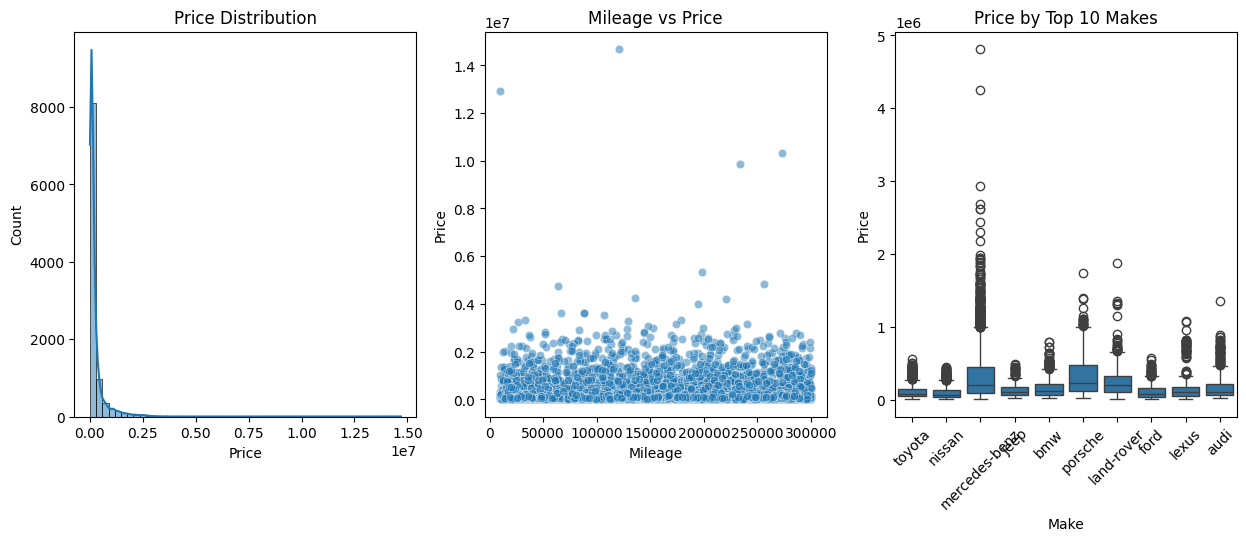

In [12]:

plt.figure(figsize=(15, 5))

# 1. Price Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Price Distribution')

# 2. Mileage vs Price
plt.subplot(1, 3, 2)
sns.scatterplot(x='Mileage', y='Price', data=df, alpha=0.5)
plt.title('Mileage vs Price')

# 3. Top 10 Makes by Price
plt.subplot(1, 3, 3)
top_makes = df['Make'].value_counts().nlargest(10).index
sns.boxplot(x='Make', y='Price', data=df[df['Make'].isin(top_makes)])
plt.xticks(rotation=45)
plt.title('Price by Top 10 Makes')

## 4. Data Cleaning
In this phase, we clean the raw dataset by handling missing values, standardizing data types, and removing extreme outliers that skew linear relationships. 
* Unstructured text columns (`Description`, `Color`) are dropped as they add noise without NLP processing.
* Critical missing values are dropped, while categorical missing values (`Cylinders`) are imputed using the mode.

In [13]:
# Drop unstructured/unnecessary columns
columns_to_drop = ['Description', 'Color']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Coerce strings (like 'Unknown') to NaN
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Cylinders'] = pd.to_numeric(df['Cylinders'], errors='coerce')

# Drop rows missing critical baseline data
df = df.dropna(subset=['Price', 'Make', 'Model', 'Year'])

# Impute missing Cylinders with the most frequent value (Mode)
df['Cylinders'] = df['Cylinders'].fillna(df['Cylinders'].mode()[0])

# Filter out outliers
df_clean = df[(df['Price'] >= 5000) & (df['Price'] <= 500000)].copy()
df_clean = df_clean[df_clean['Mileage'] <= 500000]

print(f"Data cleaned. Current shape: {df_clean.shape}")

Data cleaned. Current shape: (8896, 10)


In [14]:
df_clean.head()

,Make,Model,Year,Price,Mileage,Body Type,Cylinders,Transmission,Fuel Type,Location
0,toyota,camry,2016,47819,156500,Sedan,4.0,Automatic Transmission,Gasoline,Dubai
1,kia,sorento,2013,61250,169543,SUV,4.0,Automatic Transmission,Gasoline,Abu Dhabi
2,mini,cooper,2023,31861,221583,Soft Top Convertible,4.0,Automatic Transmission,Gasoline,Dubai
3,nissan,altima,2016,110322,69754,Sedan,4.0,Automatic Transmission,Gasoline,Dubai
4,toyota,land-cruiser-76-series,2020,139994,71399,Pick Up Truck,4.0,Manual Transmission,Gasoline,Dubai


## 5. Feature Engineering
To maximize our models' predictive power while avoiding the "Curse of Dimensionality," we engineer new features representing real-world depreciation mechanics:
1. **Age:** Derived from the current year, providing a direct linear depreciation metric.
2. **Km_per_Year:** A ratio measuring the intensity of the car's usage.
3. **Model_Rarity:** Instead of utilizing high-cardinality One-Hot Encoding for the `Model` column (which creates 400+ sparse features), we convert the car model into a mathematical frequency score. High scores indicate common cars; low scores indicate rare cars.

In [ ]:
# Age calculation
current_year = datetime.now().year
df_clean['Age'] = current_year - df_clean['Year']

# Feature 2: Km per Year (KEEP - Highly predictive of wear and tear)
df_clean['Km_per_Year'] = df_clean['Mileage'] / df_clean['Age'].replace(0, 1)

# Feature 3: Top 40 Model Grouping (THE FIX)
# Instead of rarity, we keep the actual names of the top 40 cars and bucket the rest.
top_40_models = df_clean['Model'].value_counts().nlargest(40).index
df_clean['Model'] = df_clean['Model'].where(df_clean['Model'].isin(top_40_models), 'Other')

# Check our work before encoding
print("New Features Added: 'Age', 'Km_per_Year'")
print(f"Number of unique Car Models kept: {df_clean['Model'].nunique()}")

,Make,Year,Price,Mileage,Body Type,Cylinders,Transmission,Fuel Type,Location,Age,Km_per_Year,Model_Rarity
0,toyota,2016,47819,156500,Sedan,4.0,Automatic Transmission,Gasoline,Dubai,10,15650.000000,0.007307
1,kia,2013,61250,169543,SUV,4.0,Automatic Transmission,Gasoline,Abu Dhabi,13,13041.769231,0.002023
2,mini,2023,31861,221583,Soft Top Convertible,4.0,Automatic Transmission,Gasoline,Dubai,3,73861.000000,0.004834


## 6. Categorical Encoding & Export
With the high-cardinality `Model` column safely engineered into a numeric score, we apply standard One-Hot Encoding to the remaining low-cardinality categorical variables (`Make`, `Location`, `Transmission`, `Fuel Type`, `Body Type`).

In [16]:
categorical_cols = ['Make', 'Location', 'Transmission', 'Fuel Type', 'Body Type']
cols_to_encode = [col for col in categorical_cols if col in df_clean.columns]

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=True)

# Export the dataset
file_path = "../data/uae_cars_cleaned_v2.csv"
df_encoded.to_csv(file_path, index=False)

print(f"Dataset saved to {file_path}")
print(f"Shape: {df_encoded.shape[0]} rows and {df_encoded.shape[1]} columns.")

Dataset saved to ../data/uae_cars_cleaned_v2.csv
Shape: 8896 rows and 101 columns.


## 7. Train/Validation/Test Split
We will split the data as follows: 
* **70% Training** (To train the model)
* **15% Validation** (To tune hyperparameters later)
* **15% Testing** (To evaluate final performance)

In [17]:
# Separate features (X) and target (y)
X = df_encoded.drop(['Price'], axis=1)
y = df_encoded['Price']

# First split: 70% Train, 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Second split: Split the 30% equally into 15% Val and 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Train set: (6227, 100)
Validation set: (1334, 100)
Test set: (1335, 100)


## 8. Baseline Model: Linear Regression
We will train a standard Linear Regression model to establish a baseline. All subsequent models built by the team (Random Forest, XGBoost, etc.) must beat this baseline performance.

We will evaluate the model using:
* **RMSE (Root Mean Squared Error):** The average error in AED.
* **MAE (Mean Absolute Error):** The absolute average error in AED.
* **R^2 Score:** The proportion of variance in the price that our model explains.

In [18]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on Train, Validation, and Test sets
y_pred_train = lr_model.predict(X_train)
y_pred_val = lr_model.predict(X_val)
y_pred_test = lr_model.predict(X_test)

# Function to calculate metrics
def evaluate_model(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {set_name} Performance ---")
    print(f"RMSE: AED {rmse:,.2f}")
    print(f"MAE:  AED {mae:,.2f}")
    print(f"R^2:   {r2:.4f}\n")

evaluate_model(y_train, y_pred_train, "Training Set")
evaluate_model(y_val, y_pred_val, "Validation Set")
evaluate_model(y_test, y_pred_test, "Test Set")

--- Training Set Performance ---
RMSE: AED 89,349.01
MAE:  AED 64,825.23
R^2:   0.3143

--- Validation Set Performance ---
RMSE: AED 88,806.15
MAE:  AED 65,624.54
R^2:   0.3176

--- Test Set Performance ---
RMSE: AED 89,246.08
MAE:  AED 65,414.05
R^2:   0.2882



## 9. Model Visual Evaluation
Finally, we visualize our model's performance by plotting the actual test prices against our predicted prices, and analyzing the distribution of the residual errors.

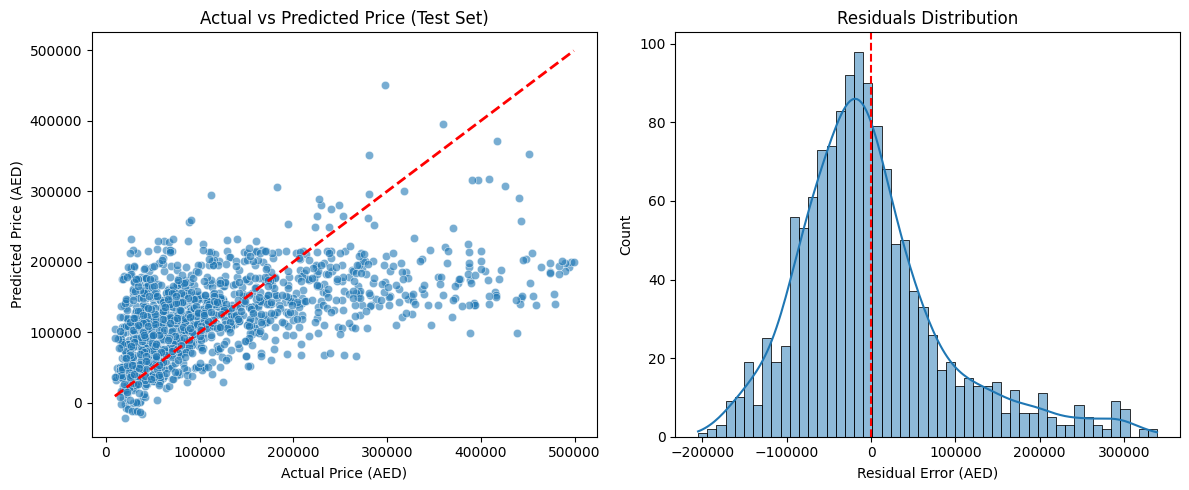

In [19]:
plt.figure(figsize=(12, 5))

# Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (AED)')
plt.ylabel('Predicted Price (AED)')
plt.title('Actual vs Predicted Price (Test Set)')

# Residuals Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_test
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel('Residual Error (AED)')
plt.title('Residuals Distribution')

plt.tight_layout()
plt.show()